# Newton–Raphson Method
---
## Learning Objectives
1. Derive Newton–Raphson iteration formula.
2. Analyze quadratic convergence.
3. Implement generalized algorithm with safeguards.
4. Study divergence and failure cases.
5. Compare with Bisection method theoretically.


## Theoretical Background

Newton–Raphson iteration:

$$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$$

If $f$ is sufficiently smooth and initial guess is close to root $\alpha$,
the method converges quadratically.

### Convergence Condition
$$
|e_{n+1}| \approx C |e_n|^2
$$

where $e_n = x_n - \alpha$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Task 1: Implement General Newton–Raphson Function
Include safeguards:
1. Division-by-zero protection
2. Maximum iterations
3. Tolerance on |f(x)| and |x_{n+1}-x_n|


In [2]:
def newton_raphson(f, df, x0, tol=1e-8, max_iter=50):
    x = x0
    history = []

    for n in range(1, max_iter+1):
        fx = f(x)
        dfx = df(x)

        if abs(dfx) < 1e-12:
            raise ZeroDivisionError('Derivative near zero. Method fails.')

        x_new = x - fx/dfx
        history.append((n, x, fx))

        if abs(fx) < tol or abs(x_new - x) < tol:
            return x_new, history

        x = x_new

    return x, history

Solve:
$x^3 - 2x - 5 = 0$
Initial guess: $x_0 = 2$

In [3]:
def f1(x):
    return x**3 - 2*x - 5

def df1(x):
    return 3*x**2 - 2

root1, hist1 = newton_raphson(f1, df1, 2)
root1

2.0945514815423265

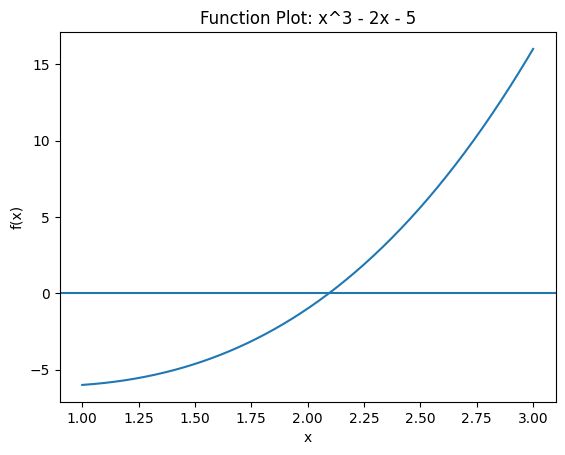

In [4]:
x = np.linspace(1, 3, 400)
y = f1(x)

plt.figure()
plt.plot(x, y)
plt.axhline(0)
plt.title('Function Plot: x^3 - 2x - 5')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

Compute error sequence and verify quadratic behavior.

In [6]:
exact_root = root1
errors = []

for n, x_val, fx_val in hist1:
    errors.append(abs(x_val - exact_root))

errors

[0.09455148154232651,
 0.005448518457673579,
 1.663956185860016e-05,
 1.5587264812211288e-10]

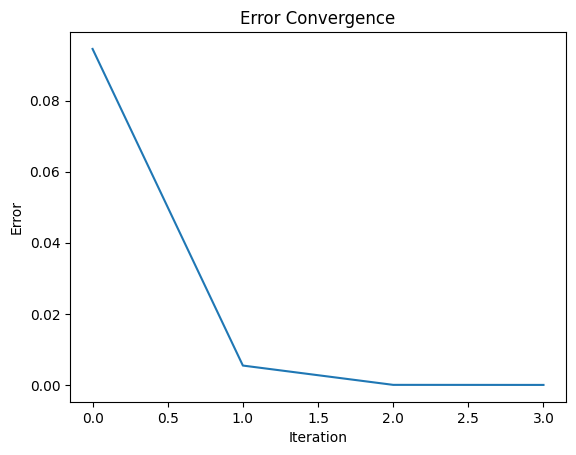

In [8]:
plt.figure()
plt.plot(errors)
plt.title('Error Convergence')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.show()

Try poor initial guess for:
$x^{1/3} = 0$
Observe instability.

In [9]:
def f_fail(x):
    return x**(1/3)

def df_fail(x):
    return (1/3)*x**(-2/3)

# Try:
# newton_raphson(f_fail, df_fail, 0.1)

Solve:
$
(x-1)^2 = 0
$
Discuss why convergence becomes linear instead of quadratic.


In [11]:
def f_multi(x):
    return (x-1)**2

def df_multi(x):
    return 2*(x-1)

root_multi, hist_multi = newton_raphson(f_multi, df_multi, 1.5)
root_multi

1.000030517578125